<a href="https://colab.research.google.com/github/geryy02/SentimenAnalysisFreeFire/blob/main/svm_nv_skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. Pengumpulan Data**
Tahapan pertama dalam penelitian ini adalah berasal dari ulasan pengguna Google Play Store pada aplikasi Free Fire. Proses yang dilakukan untuk pengumpulan data dengan menggunakan Web Scrapping Tool yaitu library **Google Play Scrapper** python. **Google Play Scrapper** adalah library yang digunakan untuk mengekstrak komentar atau secara otomatis review halaman aplikasi.

Install package library **Google Play Scrapper**

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00


Kode berikut digunakan untuk mengambil data ulasan aplikasi Free Fire dari Google Play Store menggunakan pustaka google-play-scraper. Data ini kemudian dapat digunakan sebagai dataset awal dalam proses analisis sentimen atau penelitian terkait ulasan pengguna.

1. Parameter : "com.dts.freefireth" → ID aplikasi **Free Fire**.
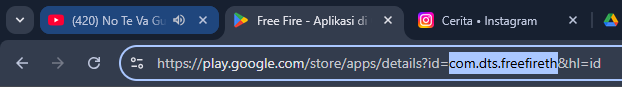
2. Parameter = "sort=Sort.NEWEST" → digunakan untuk mengambil ulasan berdasarkan urutan terbaru, sehingga ulasan yang ditampilkan adalah yang paling baru ditulis pengguna.
3. Paramter = "count=1000" → Mengambil maksimal 1.000 ulasan dalam satu permintaan.
4. Parameter = "filter_score_with=None" → mengambil semua ulasan tanpa filter (baik bintang 1–5).

Secara keseluruhan, kode ini berfungsi sebagai tahap awal dalam proses pengumpulan data untuk analisis sentimen. Dengan mendapatkan ulasan terbaru dan tidak difilter berdasarkan rating tertentu, data yang diperoleh menjadi lebih variatif dan representatif untuk dianalisis lebih lanjut menggunakan teknik pra-pemrosesan teks maupun model machine learning.


In [ ]:
from google_play_scraper import Sort, reviews

result, continuation_token = reviews(
    'com.dts.freefireth',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

reviews_list = result

if reviews_list is not None:
  print("Jumlah ulasan", len(reviews_list))
  if len(reviews_list) > 0:
    print("Contoh ulasan pertama:")
    print(reviews_list[0])
else:
  print("Gagal mengambil ulasan")

Jumlah ulasan 1000
Contoh ulasan pertama:
{'reviewId': '64f6224a-8374-4daf-b4ec-027f25510c8e', 'userName': 'Je ck', 'userImage': 'https://play-lh.googleusercontent.com/a-/ALV-UjV_uSxL2GjCTGtu9EIYRqqa6q9ipa3KKC_e96vnm3iE-wTcOMw', 'content': 'epep anj gw main ngebage demege Mulu ba bi', 'score': 1, 'thumbsUpCount': 1, 'reviewCreatedVersion': '1.118.1', 'at': datetime.datetime(2025, 12, 9, 20, 19, 53), 'replyContent': None, 'repliedAt': None, 'appVersion': '1.118.1'}


Menyimpan Data Ulasan ke dalam format file Excel.

In [ ]:
import pandas as pd
from datetime import datetime

def export_to_excel(reviews, file_name='/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil Pengumpulan Dataset Ulasan Permainan Free Fire (test) 1.xlsx'):
    if reviews:
        data = []

        for review in reviews:
            data.append({
                'Review ID': review['reviewId'],
                'Username': review['userName'],
                'Review Text': review['content'],
                'Rating': review['score'],
                'Date': review['at']
            })

        df = pd.DataFrame(data)

        # Simpan ke file Excel
        df.to_excel(file_name, index=False, engine='openpyxl')
        print(f"Data berhasil disimpan dalam {file_name}")
    else:
        print("Tidak ada data ulasan untuk diekspor")

# Panggil fungsi
export_to_excel(reviews_list)

Data berhasil disimpan dalam /content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil Pengumpulan Dataset Ulasan Permainan Free Fire (test) 1.xlsx


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil Pengumpulan Dataset Ulasan Permainan Free Fire (test) 1.xlsx')
df

,Review ID,Username,Review Text,Rating,Date
0,64f6224a-8374-4daf-b4ec-027f25510c8e,Je ck,epep anj gw main ngebage demege Mulu ba bi,1,2025-12-09 20:19:53
1,3debff25-e634-40f0-b74b-9886581e576f,Excellino Gustavio,dev tolong perketat kan keamanan akun karena a...,5,2025-12-09 18:41:15
2,48855cb7-c54c-4ba9-8977-4d41d2810eb9,Doni Damara,untuk saat ini masih Termasuk lumayan,5,2025-12-09 18:39:45
3,b043bac6-d135-4f3c-b8b1-561d3e309b5e,Malenans,game bagus,5,2025-12-09 18:28:10
4,da5ad091-9310-4b10-a424-1986be6451d4,Wagimin Gimin,sangat seru,5,2025-12-09 17:46:41
...,...,...,...,...,...
995,98dd3442-6e93-468a-9dd1-061377e85020,Maryo Jaih,keren 🗿,1,2025-12-07 11:44:23
996,5d5c7b40-d436-4d7a-8d35-c0220b1d3e19,Fikram Mrt,ff bagus,5,2025-12-07 11:40:44
997,5872e8bc-3736-4cc5-b402-39d3d0db3846,Talita Azalia,sangat seru,5,2025-12-07 11:38:59
998,58696e18-c77c-401b-ac09-c42f2a7b2ede,Hazelnut,licinin lagi sensi nya,5,2025-12-07 11:38:07


Tujuan utama penelitian:
1. Mengambil data ulasan yang paling terkini (**contoh**: Tanggal 30 Juni 2025 / perhari).
2. Melakukan pelabelan secara manual sesuai dengan setiap perulasan.

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/project gery/Skripsi/HASIL/pengumpulan & labeling data (perulasan) terkini 30 juni 2025.xlsx')
df

,Review ID,Username,Review Text,Label,Rating,Date
0,643f2b4f-c81d-4a92-99da-c65fd9c87b75,Asep Gaming,"Aku kasih bintang 5 karena gamenya bagus, mau ...",1,5,2025-06-30 23:59:41
1,31aa428e-c487-43f4-b5bc-0d4a192d5c53,Nazril Ilham23,aku sangat senang dan game ini seru banget gak...,1,5,2025-06-30 23:58:47
2,3f6cb447-34c4-4446-bd81-62fb67df1d15,Danil Tangka,game bagus,1,5,2025-06-30 23:56:10
3,56ac4776-b9dd-4bc1-a5d4-5e555c5ab963,Emailnya 1 2 34 Passwordnya Haji 80,🙏🙏🙏🙏,1,5,2025-06-30 23:45:35
4,48fb3f32-70bd-4e23-9447-c9af4eef0767,Kuala Kurun,min gua cuma mau bilang game ini bagus bangett...,1,5,2025-06-30 23:45:30
...,...,...,...,...,...,...
530,51c29144-c4de-4a50-9a9d-82310d900f45,Rere Realdeal,sangat bagus,1,5,2025-06-30 00:11:25
531,9cab782f-9a74-4eb3-bcd8-86726540e605,ff zaki,game ini sangat seru😹👍,1,5,2025-06-30 00:08:02
532,7717c8e9-1aaf-4b99-9d62-d953eef644e5,Sar Meli,gamenya bagus saya sudah bermain sejak season ...,1,5,2025-06-30 00:05:21
533,af39e1a8-285e-453e-8cc3-6417b3eb1005,Sukatendel siti,sangat bagus gamenya Semoga di kembangkan lagi...,1,5,2025-06-30 00:01:10


Mengambil kolom pada bagian **Review Text (Ulasan)** dan **Label**

In [ ]:
df_ulasan = pd.DataFrame(df[['Review Text', 'Label']])
df_ulasan

,Review Text,Label
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",1
1,aku sangat senang dan game ini seru banget gak...,1
2,game bagus,1
3,🙏🙏🙏🙏,1
4,min gua cuma mau bilang game ini bagus bangett...,1
...,...,...
530,sangat bagus,1
531,game ini sangat seru😹👍,1
532,gamenya bagus saya sudah bermain sejak season ...,1
533,sangat bagus gamenya Semoga di kembangkan lagi...,1


# **2. Labeling Data**
Tahap selanjutnya adalah pelabelan data sentimen yang perlu dilakukan sebelum proses klasifikasi untuk analisis sentimen menggunakan metode Naïve Bayes dan Support Vector Machine (SVM). Pelabelan dilakukan secara manual dengan meninjau isi review text untuk menentukan apakah ulasan bersentimen positif atau negatif, sehingga hasil pelabelan tidak hanya bergantung pada rating yang diberikan pengguna di Google Play Store. Pendekatan ini dipilih karena terdapat kemungkinan ketidaksesuaian antara rating dan isi ulasan. Misalnya, pengguna memberikan rating tinggi namun menuliskan keluhan, atau sebaliknya, memberikan rating rendah tetapi memuji aplikasi.

Terdapat pada kriteria:
- Label 0 = Negatif
- Label 1 = Positif

In [ ]:
# Menambahkan kolom sentimen (Negatif/Positif) berdasarkan label
def label_to_sentiment(label):
    if label == 0:
        return 'Negative'
    elif label == 1:
        return 'Positive'
    else:
        return 'Tidak Valid'

df_ulasan['Sentiment'] = df_ulasan['Label'].apply(label_to_sentiment)
df_ulasan

,Review Text,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",1,Positive
1,aku sangat senang dan game ini seru banget gak...,1,Positive
2,game bagus,1,Positive
3,🙏🙏🙏🙏,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,1,Positive
...,...,...,...
530,sangat bagus,1,Positive
531,game ini sangat seru😹👍,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,1,Positive


# **3. Pra-pemrosesan Data**
Tahap pra-pemrosesan data bertujuan untuk mengubah data yang belum
terstruktur menjadi data yang terstruktur. Pada penelitian ini, tahapan pra
pemrosesan yang dilakukan terdiri dari cleaning, casefolding, normalisasi data,
stopword removal, dan stemming.

In [ ]:
df_ulasan = df_ulasan.rename(columns={'Review Text': 'Teks Asli'})
df_ulasan

,Teks Asli,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",1,Positive
1,aku sangat senang dan game ini seru banget gak...,1,Positive
2,game bagus,1,Positive
3,🙏🙏🙏🙏,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,1,Positive
...,...,...,...
530,sangat bagus,1,Positive
531,game ini sangat seru😹👍,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,1,Positive


Melihat diagram jumlah dan distribusi pada sentimen awal

In [ ]:
sentiment_counts = df_ulasan['Sentiment'].value_counts().sort_index()
sentiment_counts

,count
Sentiment,
Negative,160
Positive,375


/tmp/ipython-input-3245196520.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


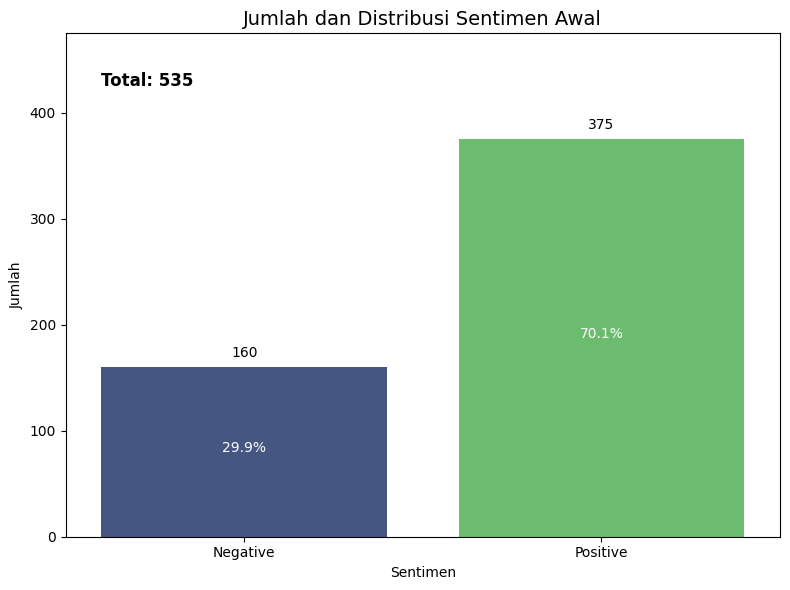

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df_ulasan['Sentiment'].value_counts().sort_index()

# Total keseluruhan
total = sentiment_counts.sum()

# Warna
colors = ['#3b528b', '#5ec962']

# Plot
plt.figure(figsize=(8, 6))
bars = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)

# Tambahkan angka & persentase ke dalam bar
for i, count in enumerate(sentiment_counts):
    bars.text(i, count + 10, f"{count}", ha='center', fontsize=10)
    bars.text(i, count / 2, f"{(count / total) * 100:.1f}%", ha='center', color='white', fontsize=10)

# Tambahkan total di pojok kiri atas grafik (tidak terlalu tinggi)
plt.text(-0.4, max(sentiment_counts) + 50, f"Total: {total}", fontsize=12, weight='bold')

# Judul dan label
plt.title("Jumlah dan Distribusi Sentimen Awal", fontsize=14)
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.ylim(0, max(sentiment_counts) + 100)  # Sesuaikan batas atas Y agar tidak terlalu jauh

plt.tight_layout()
plt.show()

**a. Cleaning** merupakan tahapan pra-pemrosesan yang dilakukan dengan
menghapus beberapa hal yang tidak diperlukan pada data, seperti emoticon,
tanda baca, angka, link, mention, hashtag, dan lainnya. Pada penelitian ini
cleaning data dilakukan menggunakan library Regex (Regular Expression).

In [ ]:
import re
import string

#Fungsi untuk menghapus url
def remove_URL(tweet):
  if tweet is not None and isinstance(tweet, str):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', tweet)
  else:
    return tweet

#Fungsi untuk menghapus HTML
def remove_html(tweet):
  if tweet is not None and isinstance(tweet, str):
    html = re.compile(r'<.*?>')
    return html.sub(r'', tweet)
  else:
    return tweet

#Fungsi untuk menghapus tanda baca
def remove_emoji(tweet):
  if tweet is not None and isinstance(tweet, str):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # Emoticons
        "\U0001F300-\U0001F5FF"  # Simbol dan Objek
        "\U0001F680-\U0001F6FF"  # Transportasi dan Simbol
        "\U0001F700-\U0001F77F"  # Simbol Alkimia
        "\U0001F780-\U0001F7FF"  # Simbol Geometris tambahan
        "\U0001F800-\U0001F8FF"  # Simbol Panah tambahan
        "\U0001F900-\U0001F9FF"  # Karakter tambahan (termasuk gestur, dll.)
        "\U0001FA00-\U0001FA6F"  # Simbol Objek tambahan
        "\U0001FA70-\U0001FAFF"  # Simbol Objek lainnya
        "\U00002600-\U000026FF"  # Simbol Misc
        "\U00002700-\U000027BF"  # Dingbats
        "\U00002B50-\U00002B55"  # Simbol Misc tambahan
        "\U00002300-\U000023FF"  # Simbol Misc tambahan lainnya
        "\U00002500-\U000025FF"  # Simbol Geometris
        "\U0001F1E0-\U0001F1FF"  # Bendera Regional
        "\U0001F200-\U0001F2FF"  # Simbol Teks
        "] + ",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', tweet)
  else:
    return tweet

#Fungsi untuk menghapus simbol
def remove_symbols(tweet):
  if tweet is not None and isinstance(tweet, str):
    tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
  return tweet

#Fungsi untuk menghapus angka
def remove_number(tweet):
  if tweet is not None and isinstance(tweet, str):
    tweet = re.sub(r'\d+', '', tweet)
  return tweet

df_ulasan['Hasil Cleaning Data'] = df_ulasan['Teks Asli'].apply(lambda x: remove_URL(x))
df_ulasan['Hasil Cleaning Data'] = df_ulasan['Hasil Cleaning Data'].apply(lambda x: remove_html(x))
df_ulasan['Hasil Cleaning Data'] = df_ulasan['Hasil Cleaning Data'].apply(lambda x: remove_emoji(x))
df_ulasan['Hasil Cleaning Data'] = df_ulasan['Hasil Cleaning Data'].apply(lambda x: remove_symbols(x))
df_ulasan['Hasil Cleaning Data'] = df_ulasan['Hasil Cleaning Data'].apply(lambda x: remove_number(x))

df_ulasan = pd.DataFrame(df_ulasan[['Teks Asli', 'Hasil Cleaning Data', 'Label', 'Sentiment']])
df_ulasan

,Teks Asli,Hasil Cleaning Data,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,1,Positive
2,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,1,Positive
...,...,...,...,...
530,sangat bagus,sangat bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,1,Positive


b. **Casefolding** yang dilakukan dengan mengubah seluruh karakter menjadi
bentuk yang sama, baik itu menjadi huruf kecil atau lowercase maupun huruf
besar atau uppercase. Pada penelitian ini, seluruh data akan diubah menjadi
huruf kecil atau lowercase.

In [ ]:
def case_folding(text):
  lwr = text.lower()
  return lwr

df_ulasan['Hasil Casefolding'] = df_ulasan['Hasil Cleaning Data'].apply(case_folding)

df_ulasan = pd.DataFrame(df_ulasan[['Teks Asli', 'Hasil Cleaning Data', 'Hasil Casefolding', 'Label', 'Sentiment']])
df_ulasan

,Teks Asli,Hasil Cleaning Data,Hasil Casefolding,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau it...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,1,Positive
2,game bagus,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,,,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,1,Positive
...,...,...,...,...,...
530,sangat bagus,sangat bagus,sangat bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,game ini sangat seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi...,1,Positive


a. **Normalisasi data** yang dilakukan dengan mengubah komentar yang tidak baku
karena tidak cocok dengan Kamus Besar Bahasa Indonesia (KBBI), meliputi
kesalahan penulisan, adanya singkatan, penggunaan bahasa daerah maupun
bahasa gaul. Sebagai contoh, singkatan “yg” ketika melewati proses
normalisasi maka berubah menjadi kata ”yang”.

SET UP KAAGLE (Kamus kata baku)

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gery17","key":"c28d3a9348c6b2577eb99a0071c43124"}'}

In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d fornigulo/kamus-slag
!unzip kamus-slag.zip

Dataset URL: https://www.kaggle.com/datasets/fornigulo/kamus-slag
License(s): RAIL
  0% 0.00/248k [00:00<?, ?B/s]
100% 248k/248k [00:00<00:00, 611MB/s]
Archive:  kamus-slag.zip
  inflating: kamuskatabaku.xlsx      


Fungsi penggantian kata tidak baku

In [ ]:
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                #else:
                #    replaced_words.append('<karakter eksplisit>')
                #    kalimat_baku.append(word)
            else:
                replaced_words.append(word)

        # Pastikan replaced_text diisi dengan benar
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

Baca kamus kata tidak baku

In [ ]:
kamus_data = pd.read_excel("kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

Terapkan fungsi penggantian kata tidak baku

In [ ]:
df_ulasan['Hasil Normalisasi'], df_ulasan['kata_baku'], df_ulasan['kata_tidak_baku'], df_ulasan['kata_tidak_baku_hash'] = zip(*df_ulasan['Hasil Casefolding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))
# df.head(100)

df_ulasan = pd.DataFrame(df_ulasan[['Teks Asli', 'Hasil Cleaning Data', 'Hasil Casefolding', 'Hasil Normalisasi', 'Label', 'Sentiment']])
df_ulasan

,Teks Asli,Hasil Cleaning Data,Hasil Casefolding,Hasil Normalisasi,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau itu...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget tid...,1,Positive
2,game bagus,game bagus,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,,,,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus banget ...,1,Positive
...,...,...,...,...,...,...
530,sangat bagus,sangat bagus,sangat bagus,sangat bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,game ini sangat seru,game ini sangat seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi ya,1,Positive


d. **Stopword removal** dilakukan dengan menghilangkan kata yang dianggap tidak
penting seperti kata hubung dan kata ganti orang. Pada penelitian ini, stopword removal dilakukan dengan menggunakan daftar stopwords untuk bahasa
Indonesia yang ada pada library nltk python.

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stopword = set(stopwords.words('indonesian'))

def clean_stopwords(text):
    text = ' '.join(word for word in text.split() if word not in stopword)
    return text

df_ulasan['Hasil Stopword Removal'] = df_ulasan['Hasil Normalisasi'].apply(lambda x: clean_stopwords(x))

df_ulasan = pd.DataFrame(df_ulasan[['Teks Asli', 'Hasil Cleaning Data', 'Hasil Casefolding', 'Hasil Normalisasi', 'Hasil Stopword Removal', 'Label', 'Sentiment']])
df_ulasan

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Teks Asli,Hasil Cleaning Data,Hasil Casefolding,Hasil Normalisasi,Hasil Stopword Removal,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau itu...,kasih bintang gamenya bagus grafik gameplay ba...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget tid...,senang game seru banget kayak mobile legends b...,1,Positive
2,game bagus,game bagus,game bagus,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,,,,,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus banget ...,min gua bilang game bagus banget min bilang te...,1,Positive
...,...,...,...,...,...,...,...
530,sangat bagus,sangat bagus,sangat bagus,sangat bagus,bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,game ini sangat seru,game ini sangat seru,game seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus bermain season grafiknya bagus h...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi ya,bagus gamenya semoga kembangkan ya,1,Positive


e. **Stemming** yang dilakukan dengan menghilangkan kata imbuhan sehingga kata
tersebut menjadi kata dasar. Pada penelitian ini, stemming dilakukan dengan
menggunakan library python Sastrawi.

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.5 MB/s eta 0:00:00


In [ ]:
#Stemming
#Sastrawi

# import Sastrawi package
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def get_stemmed_term(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    hasil = stemmer.stem(text)
    return hasil

df_ulasan['Hasil Stemming'] = df_ulasan['Hasil Stopword Removal'].apply(get_stemmed_term)

df_ulasan = pd.DataFrame(df_ulasan[['Teks Asli', 'Hasil Cleaning Data', 'Hasil Casefolding', 'Hasil Normalisasi', 'Hasil Stopword Removal', 'Hasil Stemming', 'Label', 'Sentiment']])
df_ulasan

,Teks Asli,Hasil Cleaning Data,Hasil Casefolding,Hasil Normalisasi,Hasil Stopword Removal,Hasil Stemming,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau itu...,kasih bintang gamenya bagus grafik gameplay ba...,kasih bintang gamenya bagus grafik gameplay ba...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget tid...,senang game seru banget kayak mobile legends b...,senang game seru banget kayak mobile legends b...,1,Positive
2,game bagus,game bagus,game bagus,game bagus,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,,,,,,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus banget ...,min gua bilang game bagus banget min bilang te...,min gua bilang game bagus banget min bilang te...,1,Positive
...,...,...,...,...,...,...,...,...
530,sangat bagus,sangat bagus,sangat bagus,sangat bagus,bagus,bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,game ini sangat seru,game ini sangat seru,game seru,game seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus bermain season grafiknya bagus h...,gamenya bagus main season grafik bagus hd coco...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi ya,bagus gamenya semoga kembangkan ya,bagus gamenya moga kembang ya,1,Positive


Menyimpan Hasil Pra-Pemrosesan Data

In [ ]:
df_ulasan.to_excel('/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil pra-pemrosesan data ulasan permainan free fire.xlsx', index=False)

# **4. Pembagian Data**
Setelah melalui tahapan pra-pemrosesan data, data dibagi menjadi dua bagian yakni data latih dan data uji. Data latih digunakan untuk melatih model sehingga mampu mengenali pola data, sedangkan data uji digunakan untuk menguji performa model yang telah dibangun.

Tapi sebelum itu kita harus melakukan melihat jumlah data terlebih dahulu

In [ ]:
df_ulasan = pd.read_excel("/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil pra-pemrosesan data ulasan permainan free fire.xlsx")
df_ulasan

,Teks Asli,Hasil Cleaning Data,Hasil Casefolding,Hasil Normalisasi,Hasil Stopword Removal,Hasil Stemming,Label,Sentiment
0,"Aku kasih bintang 5 karena gamenya bagus, mau ...",Aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau it...,aku kasih bintang karena gamenya bagus mau itu...,kasih bintang gamenya bagus grafik gameplay ba...,kasih bintang gamenya bagus grafik gameplay ba...,1,Positive
1,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget gak...,aku sangat senang dan game ini seru banget tid...,senang game seru banget kayak mobile legends b...,senang game seru banget kayak mobile legends b...,1,Positive
2,game bagus,game bagus,game bagus,game bagus,game bagus,game bagus,1,Positive
3,🙏🙏🙏🙏,NaN,NaN,NaN,NaN,NaN,1,Positive
4,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus bangett...,min gua cuma mau bilang game ini bagus banget ...,min gua bilang game bagus banget min bilang te...,min gua bilang game bagus banget min bilang te...,1,Positive
...,...,...,...,...,...,...,...,...
530,sangat bagus,sangat bagus,sangat bagus,sangat bagus,bagus,bagus,1,Positive
531,game ini sangat seru😹👍,game ini sangat seru,game ini sangat seru,game ini sangat seru,game seru,game seru,1,Positive
532,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus saya sudah bermain sejak season ...,gamenya bagus bermain season grafiknya bagus h...,gamenya bagus main season grafik bagus hd coco...,1,Positive
533,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya Semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi...,sangat bagus gamenya semoga di kembangkan lagi ya,bagus gamenya semoga kembangkan ya,bagus gamenya moga kembang ya,1,Positive


In [ ]:
df_ulasan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Teks Asli               535 non-null    object
 1   Hasil Cleaning Data     528 non-null    object
 2   Hasil Casefolding       528 non-null    object
 3   Hasil Normalisasi       528 non-null    object
 4   Hasil Stopword Removal  523 non-null    object
 5   Hasil Stemming          523 non-null    object
 6   Label                   535 non-null    int64 
 7   Sentiment               535 non-null    object
dtypes: int64(1), object(7)
memory usage: 33.6+ KB


Melihat jumlah data (Setelah Hapus Data Yang Mengandung Kosong)

In [ ]:
df_ulasan = df_ulasan.dropna()
df_ulasan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 523 entries, 0 to 534
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Teks Asli               523 non-null    object
 1   Hasil Cleaning Data     523 non-null    object
 2   Hasil Casefolding       523 non-null    object
 3   Hasil Normalisasi       523 non-null    object
 4   Hasil Stopword Removal  523 non-null    object
 5   Hasil Stemming          523 non-null    object
 6   Label                   523 non-null    int64 
 7   Sentiment               523 non-null    object
dtypes: int64(1), object(7)
memory usage: 36.8+ KB


In [ ]:
sentiment_counts = df_ulasan['Sentiment'].value_counts().sort_index()
sentiment_counts

,count
Sentiment,
Negative,158
Positive,365


/tmp/ipython-input-1792028380.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


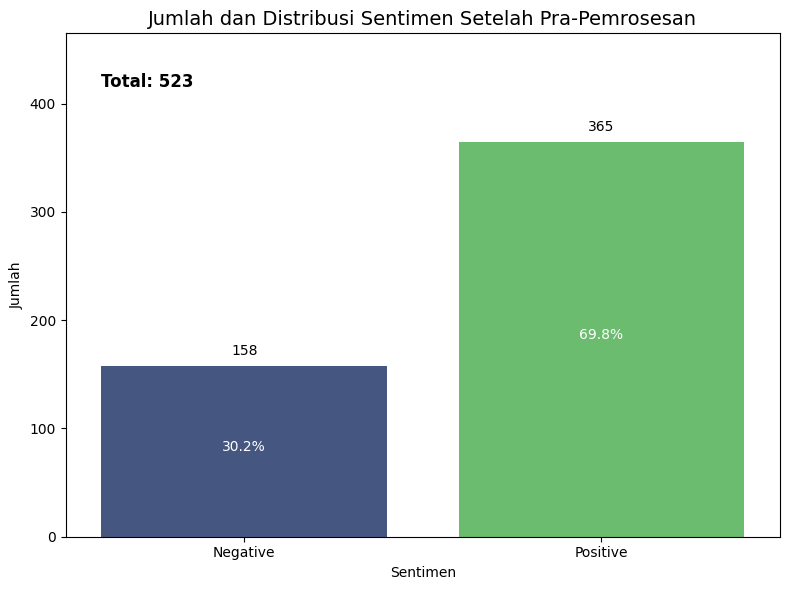

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df_ulasan['Sentiment'].value_counts().sort_index()

# Total keseluruhan
total = sentiment_counts.sum()

# Warna
colors = ['#3b528b', '#5ec962']

# Plot
plt.figure(figsize=(8, 6))
bars = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)

# Tambahkan angka & persentase ke dalam bar
for i, count in enumerate(sentiment_counts):
    bars.text(i, count + 10, f"{count}", ha='center', fontsize=10)
    bars.text(i, count / 2, f"{(count / total) * 100:.1f}%", ha='center', color='white', fontsize=10)

# Tambahkan total di pojok kiri atas grafik
plt.text(-0.4, max(sentiment_counts) + 50, f"Total: {total}", fontsize=12, weight='bold')

# Judul dan label
plt.title("Jumlah dan Distribusi Sentimen Setelah Pra-Pemrosesan", fontsize=14)
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.ylim(0, max(sentiment_counts) + 100)

plt.tight_layout()
plt.show()

Membuat variabel **"data_ulasan"** berisi kolom Hasil Stemming (Setelah dilakukan pra-pemrosesan dan juga variabel **label_sentimen** berisi kolom Sentimen

In [ ]:
data_ulasan = df_ulasan['Hasil Stemming']
data_sentimen = df_ulasan['Sentiment']

Pada penelitian ini, perbandingan pembagian
data yang digunakan adalah 70:30, di mana 70% akan digunakan sebagai data latih
dan 30% sebagai data uji dengan memanfaatkan library Scikit-learn python. Agar proses pembagian menghasilkan distribusi yang konsisten setiap kali dijalankan, digunakan parameter random_state = 42. Selain itu, penerapan parameter stratify = y bertujuan untuk menjaga keseimbangan proporsi antara label sentimen positif dan negatif pada kedua subset data, sehingga tetap merepresentasikan kondisi asli dataset

In [ ]:
from sklearn.model_selection import train_test_split

ulasan_latih, ulasan_uji, sentimen_latih, sentimen_uji = train_test_split(
    data_ulasan,
    data_sentimen,
    test_size=0.3, #70:30
    random_state=42,
    stratify=data_sentimen #proporsi label sentimen pada data latih dan data uji tetap seimbang seperti data asli.
)

In [ ]:
print("==== Split Dataset ====")
print(f"Jumlah data latih : {ulasan_latih.shape[0]}")
print(f"Jumlah data uji   : {ulasan_uji.shape[0]}")
print("=======================")

==== Split Dataset ====
Jumlah data latih : 366
Jumlah data uji   : 157


Melihat jumlah pada Data Latih dan Data Uji

In [ ]:
ulasan_latih, sentimen_latih

(328    mantap bug damage tambah seru beda kemarin ter...
 224                 wajib sih bintang seru banget sumpah
 186                                   bagus game play ya
 269                                        gamenya hebat
 355    gamenya seru kendala gamenya kereta lobi updat...
                              ...                        
 447    garena tolong baik jaring adu mekanik musuh la...
 530                                                bagus
 110    bagus suka skill ya enteng pakai skil kely baw...
 314                                        diamond batas
 26                             pas login black screen ya
 Name: Hasil Stemming, Length: 366, dtype: object,
 328    Positive
 224    Positive
 186    Positive
 269    Positive
 355    Negative
          ...   
 447    Negative
 530    Positive
 110    Positive
 314    Positive
 26     Negative
 Name: Sentiment, Length: 366, dtype: object)

In [ ]:
ulasan_uji, sentimen_uji

(276                           plis update hp ku kuat min
 299                                 bagus banget gamenya
 192                       gamenya bagus bug pokok mantap
 489    kecewa gua game email pulih gua kait akun gua ...
 448                                    main main ff seru
                              ...                        
 214                                                bagus
 13     admin garena gamenya bagus banget event top cr...
 220                                               mantap
 402    jaring jelek ketemu musuh pas musuh jaring put...
 100                                                bagus
 Name: Hasil Stemming, Length: 157, dtype: object,
 276    Negative
 299    Positive
 192    Positive
 489    Negative
 448    Positive
          ...   
 214    Positive
 13     Negative
 220    Positive
 402    Negative
 100    Positive
 Name: Sentiment, Length: 157, dtype: object)

In [ ]:
sentimen_latih.value_counts()

,count
Sentiment,
Positive,255
Negative,111


In [ ]:
sentimen_uji.value_counts()

,count
Sentiment,
Positive,110
Negative,47


# **5. Ekstraksi Fitur dengan TF-IDF**
Tahapan berikutnya dalam penelitian ini adalah ekstraksi fitur dengan
memanfaatkan teknik *Term Frequency–Inverse Document Frequency* (TF-IDF).
Proses ini dilakukan pada data pelatihan dan data pengujian, sehingga
menghasilkan dua keluaran, yaitu bobot TF-IDF untuk data latih dan bobot TF-IDF
untuk data uji.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

TfidfVectorizer = TfidfVectorizer(max_features=1000)
data_latih_tfidf = TfidfVectorizer.fit_transform(ulasan_latih) #Data latih
data_uji_tfidf = TfidfVectorizer.transform(ulasan_uji) #Data uji

Hasil Keluaran pada TF-IDF

In [ ]:
print("=====================================")
print("Hasil TF-IDF (Data latih):")
print(data_latih_tfidf)
print("=====================================")
df_data_latih_tfidf = pd.DataFrame(data_latih_tfidf.toarray(),
                               columns=TfidfVectorizer.get_feature_names_out(),
                               index=range(1, data_latih_tfidf.shape[0] + 1)) # jumlah data latih
print("=====================================")
print("Hasil TF-IDF (Data uji):")
print(data_uji_tfidf)
print("=====================================")
df_data_uji_tfidf = pd.DataFrame(data_uji_tfidf.toarray(),
                               columns=TfidfVectorizer.get_feature_names_out(),
                               index=range(1, data_uji_tfidf.shape[0] + 1)) # jumlah data uji

# Simpan data Hasil TF-IDF (Data latih & Data Uji)
df_data_latih_tfidf.T.to_excel("/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil TFIDF Latih.xlsx", index=True)
df_data_uji_tfidf.T.to_excel("/content/drive/MyDrive/project gery/Skripsi/HASIL/Hasil TFIDF Uji.xlsx", index=True)

Hasil TF-IDF (Data latih):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1684 stored elements and shape (366, 512)>
  Coords	Values
  (0, 284)	0.27577816464406707
  (0, 75)	0.2637989959435028
  (0, 107)	0.362622180604276
  (0, 456)	0.3815239064266507
  (0, 424)	0.1846937404403853
  (0, 52)	0.4081643927061169
  (0, 232)	0.4081643927061169
  (0, 469)	0.3359816943248098
  (0, 224)	0.2371585096640366
  (0, 153)	0.2021513746475501
  (1, 424)	0.2541333928054385
  (1, 504)	0.5616227257807789
  (1, 428)	0.3448381245833138
  (1, 63)	0.37362831650016537
  (1, 41)	0.293078839559166
  (1, 450)	0.5249661658559841
  (2, 31)	0.28598004077060524
  (2, 146)	0.3248262998513273
  (2, 368)	0.7840964710743433
  (2, 511)	0.4448550497122628
  (3, 147)	0.45172815842358566
  (3, 178)	0.8921556315392712
  (4, 424)	0.12917654426536276
  (4, 146)	0.11054393686391688
  (4, 511)	0.15139177015991256
  :	:
  (361, 314)	0.20869408022243935
  (361, 505)	0.21957228485554753
  (361, 260)	0.208694080222439

Hasil TF-IDF Data Latih & Data Uji

In [ ]:
# Tampilkan hasil TF-IDF (Token/Kata sebagai baris)
df_data_latih_tfidf.T.sort_index()

,1,2,3,4,5,6,7,8,9,10,...,357,358,359,360,361,362,363,364,365,366
abang,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
adil,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
admin,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
adu,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.234904,0.0,0.00000,0.0,0.000000
aduh,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
win,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
wish,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
woi,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000
wow,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000


In [ ]:
# Tampilkan hasil TF-IDF (Token/Kata sebagai baris)
df_data_uji_tfidf.T.sort_index()

,1,2,3,4,5,6,7,8,9,10,...,148,149,150,151,152,153,154,155,156,157
abang,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
adil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
admin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.314116,0.0,0.0,0.0
adu,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
aduh,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
win,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
wish,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
woi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
wow,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


Visualiasi TF-IDF dengan menggunakan Word Cloud dan Barchart

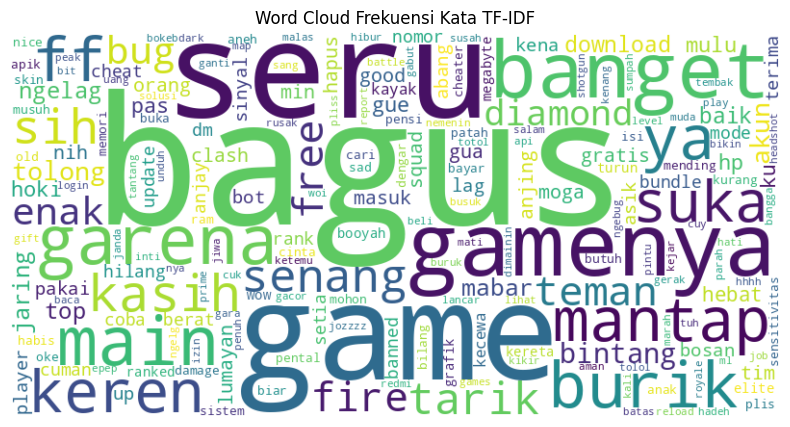

/tmp/ipython-input-2608666935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kata_terbaik.values, y=kata_terbaik.index, palette='viridis')


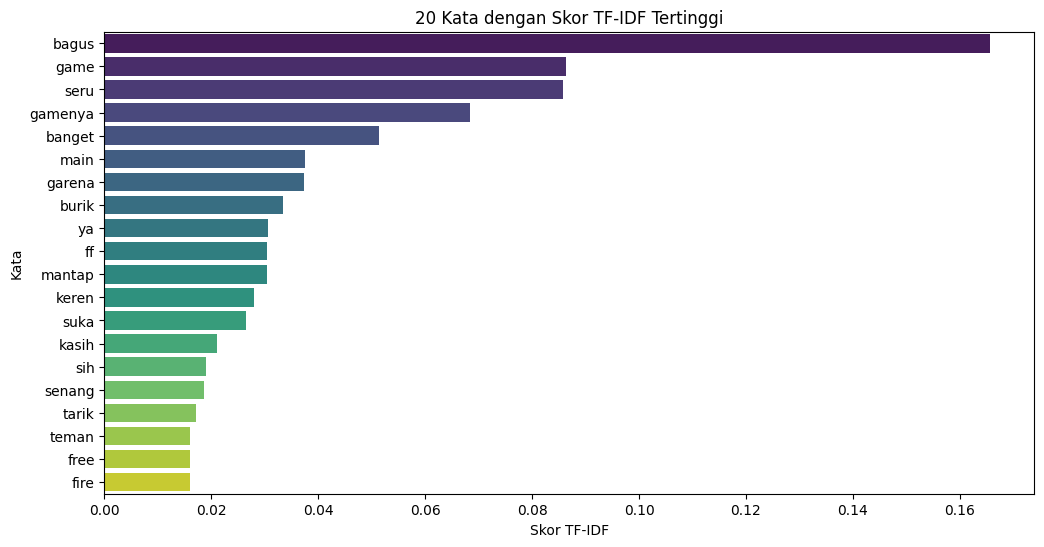

In [ ]:
from wordcloud import WordCloud

# Frekuensi kata berdasarkan TF-IDF melalui word cloud dan bar chart
skor_tfidf = df_data_latih_tfidf.mean(axis=0).sort_values(ascending=False)
kamus_tfidf = skor_tfidf.to_dict()
# Buat word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(kamus_tfidf)
# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Frekuensi Kata TF-IDF')
plt.show()

# Ambil 20 kata dengan skor TF-IDF tertinggi
kata_terbaik = skor_tfidf.head(20)
# Tampilan bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=kata_terbaik.values, y=kata_terbaik.index, palette='viridis')
plt.title('20 Kata dengan Skor TF-IDF Tertinggi')
plt.xlabel('Skor TF-IDF')
plt.ylabel('Kata')
plt.show()

# **6. Klasifikasi Naive Bayes dan SVM**
Pada penelitian ini, proses klasifikasi untuk analisis sentimen dilakukan
dengan membandingkan dua metode, yaitu *Naive Bayes* dan *Support Vector Machine* (SVM). Perbandingan metode dilakukan untuk menentukan metode yang
tepat dalam pembuatan model analisis sentimen dengan melihat performa model
yang dihasilkan oleh masing-masing metode. Dalam penelitian ini, model
klasifikasi Naïve Bayes yang digunakan adalah *Naive Bayes Multinomial* yang
memiliki kemampuan untuk bekerja optimal pada data teks dengan representasi
frekuensi kata atau bobot TF-IDF, karena asumsi dasarnya adalah bahwa fitur
berupa kata-kata dalam dokumen bersifat independen satu sama lain, sedangkan pada metode SVM, digunakan kernel linear yang memiliki kemampuan untuk memisahkan data ke dalam kelas-kelas berbeda dengan memanfaatkan hyperplane terbaik dalam ruang berdimensi tinggi. Kernel ini bekerja efektif ketika data relatif dapat dipisahkan secara linear, dan memberikan hasil yang baik dalam analisis sentimen karena mampu menangani data berdimensi besar seperti teks dengan efisiensi yang tinggi.

Skenario 1 **BASELINE** (Tanpa Penyeimbangan Data)

Skenario pengujian model analisis sentimen menggunakan metode klasifikasi
model Naive Bayes dan SVM dengan pendekatan baseline tanpa metode
oversampling. Pada skenario pengujian ini, kedua model dilatih menggunakan
data latih asli yang memiliki distribusi kelas tidak seimbang tanpa dilakukan
proses penyeimbangan data terlebih dahulu. Skenario ini bertujuan untuk
memperoleh gambaran performa awal dari masing-masing model klasifikasi
sebagai acuan pembanding sebelum diterapkannya metode penanganan
ketidakseimbangan data.

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear')
model_svm.fit(data_latih_tfidf, sentimen_latih)

SVC(kernel='linear')

In [ ]:
from sklearn.naive_bayes import MultinomialNB

#Implementasi Model Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(data_latih_tfidf, sentimen_latih)

MultinomialNB()

Skenario 2 **OVERSAMPLING** (TF-IDF + SMOTE)

Skenario pengujian model analisis sentimen menggunakan gabungan metode
klasifikasi dengan metode oversampling, salah satunya adalah SMOTE. Pada
skenario pengujian ini, data latih terlebih dahulu diproses menggunakan
metode *Synthetic Minority Over-sampling Technique* (SMOTE) untuk
menyeimbangkan distribusi jumlah data antar kelas. Data yang telah di
oversampling tersebut kemudian digunakan untuk melatih model Naive Bayes
dan SVM. Tujuan dari skenario ini adalah untuk mengevaluasi apakah
penerapan SMOTE dapat meningkatkan performa model dalam melakukan
klasifikasi sentimen, khususnya dalam menangani data yang tidak seimbang.

=========== Setelah SMOTE ============
Jumlah data latih sebelum SMOTE : 366
Jumlah data latih setelah SMOTE : 510
Distribusi label setelah SMOTE:
Sentiment
Positive    255
Negative    255
Name: count, dtype: int64


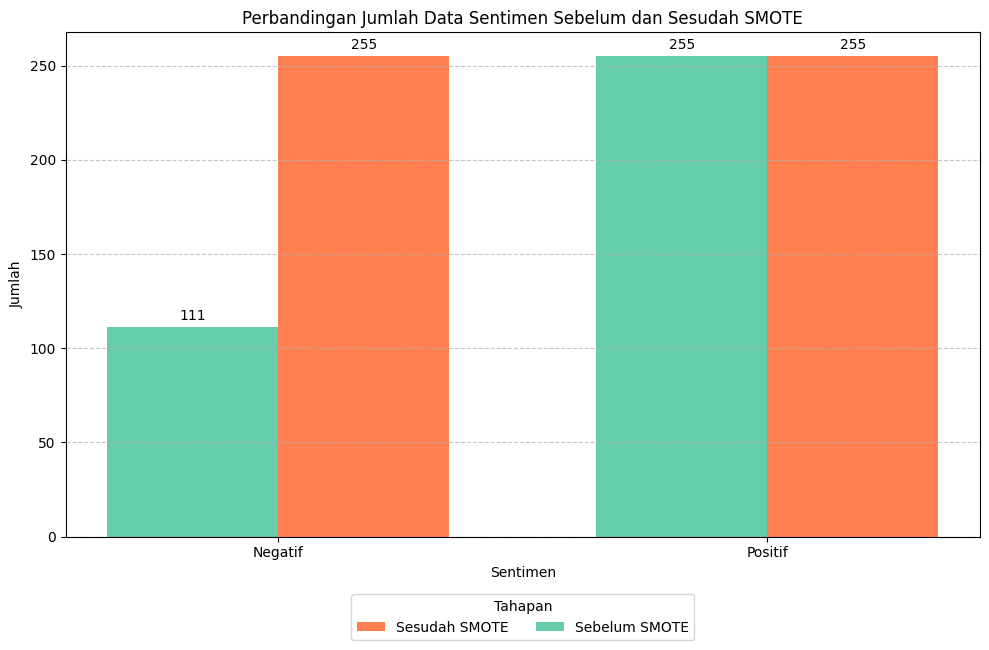

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Terapkan SMOTE pada data latih TF-IDF
smote = SMOTE()
ulasan_latih_smote, sentimen_latih_smote = smote.fit_resample(data_latih_tfidf, sentimen_latih)

# Cek hasil balancing
print("=========== Setelah SMOTE ============")
print("Jumlah data latih sebelum SMOTE :", data_latih_tfidf.shape[0])
print("Jumlah data latih setelah SMOTE :", ulasan_latih_smote.shape[0])
print("Distribusi label setelah SMOTE:")
print(pd.Series(sentimen_latih_smote).value_counts())
print("======================================")

# Hasil Visualiasi
# Perbandingan jumlah data sentimen sebelum dan setelah SMOTE
labels = ['Negatif', 'Positif'] # Updated labels
sebelum_smote = sentimen_latih.value_counts().sort_index()
setelah_smote = sentimen_latih_smote.value_counts().sort_index()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars2 = ax.bar(x + width/2, setelah_smote, width, label='Sesudah SMOTE', color='coral')
bars1 = ax.bar(x - width/2, sebelum_smote, width, label='Sebelum SMOTE', color='mediumaquamarine')

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # offset label
                textcoords="offset points",
                ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

ax.set_title('Perbandingan Jumlah Data Sentimen Sebelum dan Sesudah SMOTE')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(title='Tahapan')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(
    title='Tahapan',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2
)

plt.show()

In [ ]:
model_svm_smote = SVC(kernel='linear')
model_svm_smote.fit(ulasan_latih_smote, sentimen_latih_smote)

SVC(kernel='linear')

In [ ]:
model_nb_smote = MultinomialNB()
model_nb_smote.fit(ulasan_latih_smote, sentimen_latih_smote)

MultinomialNB()

# **7. Evaluasi dan Visualisasi**
Tahap selanjutnya adalah evaluasi terhadap model klasifikasi yang
dirancang menggunakan komparasi model Naive Bayes dan SVM. Hasil evaluasi
menujukkan kinerja setiap metode terhadap klasifikasi yang akan dilakukan pada
penelitian ini. Evaluasi terhadap model klasifikasi akan dilakukan dengan
menggunakan Confusion Matrix.

Untuk mengukur akurasi model, proses pengujiannya dilakukan dengan
cara membandingkan hasil prediksi model dengan label sebenarnya pada data uji.
Setiap data uji yang diprediksi kemudian dikategorikan apakah prediksi tersebut
benar atau salah. Jika prediksi model sesuai dengan label asli, maka masuk kategori
benar (True), dan jika tidak sesuai maka masuk kategori salah (False). Dari proses
tersebut dapat diketahui jumlah data yang benar diklasifikasikan sebagai kelas
positif (True Positive), jumlah yang benar diklasifikasikan sebagai negatif (True
Negative), serta jumlah kesalahan prediksi berupa data yang harusnya negatif
namun diprediksi positif (False Positive), dan data yang seharusnya positif tetapi
diprediksi sebagai negatif (False Negative). Berdasarkan pembagian ini, model
kemudian dievaluasi sehingga dapat diketahui sejauh mana prediksi yang
dihasilkan valid atau tidak, serta apakah model mampu membedakan data positif
dan negatif dengan baik.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**SKENARIO 1** BASELINE: TF-IDF

In [ ]:
# Evaluasi
# Skenario 1: TF-IDF
# SVM
prediksi_svm = model_svm.predict(data_uji_tfidf)
conf_matrix_svm = confusion_matrix(sentimen_uji, prediksi_svm)
akurasi_svm = accuracy_score(sentimen_uji, prediksi_svm)

# output
print("\n======== Hasil Evaluasi Model SVM (Skenario 1: TF-IDF) ========")
print(f"Akurasi - SVM (Linear): {akurasi_svm}\n")
print("Laporan Klasifikasi Evaluasi Kinerja - Model SVM")
print(classification_report(sentimen_uji, prediksi_svm))
print("Confusion Matrix - SVM:")
print(conf_matrix_svm)
print("===============================================================")

# NB
prediksi_nb = model_nb.predict(data_uji_tfidf)
conf_matrix_nb = confusion_matrix(sentimen_uji, prediksi_nb)
akurasi_nb = accuracy_score(sentimen_uji, prediksi_nb)

# output
print("\n======== Hasil Evaluasi Model Naive Bayes (Skenario 1: TF-IDF) ========")
print(f"Akurasi - Naive Bayes: {akurasi_nb}\n")
print("Laporan klasifikasi Evaluasi Kinerja - Model Naive Bayes")
print(classification_report(sentimen_uji, prediksi_nb))
print("Confusion Matrix - Naive Bayes:")
print(conf_matrix_nb)
print("=======================================================================")


======== Hasil Evaluasi Model SVM (Skenario 1: TF-IDF) ========
Akurasi - SVM (Linear): 0.8980891719745223

Laporan Klasifikasi Evaluasi Kinerja - Model SVM
              precision    recall  f1-score   support

    Negative       0.84      0.81      0.83        47
    Positive       0.92      0.94      0.93       110

    accuracy                           0.90       157
   macro avg       0.88      0.87      0.88       157
weighted avg       0.90      0.90      0.90       157

Confusion Matrix - SVM:
[[ 38   9]
 [  7 103]]

======== Hasil Evaluasi Model Naive Bayes (Skenario 1: TF-IDF) ========
Akurasi - Naive Bayes: 0.8280254777070064

Laporan klasifikasi Evaluasi Kinerja - Model Naive Bayes
              precision    recall  f1-score   support

    Negative       0.95      0.45      0.61        47
    Positive       0.81      0.99      0.89       110

    accuracy                           0.83       157
   macro avg       0.88      0.72      0.75       157
weighted avg       0.85

**SKENARIO 2** OVERSAMPLING MENGGUNAKAN SMOTE

In [ ]:
# Evaluasi
# Skenario 2: Dengan Oversampling menggunakan SMOTE
# SVM
prediksi_svm_smote = model_svm_smote.predict(data_uji_tfidf)
conf_matrix_svm_smote = confusion_matrix(sentimen_uji, prediksi_svm_smote)
akurasi_svm_smote = accuracy_score(sentimen_uji, prediksi_svm_smote)

print("\n======== Hasil Evaluasi Model SVM (Skenario 2: TF-IDF + SMOTE) ========")
print(f"Akurasi - SVM (Linear + SMOTE): {akurasi_svm_smote}\n")
print("Laporan Klasifikasi Evaluasi Kinerja - Model SVM + SMOTE")
print(classification_report(sentimen_uji, prediksi_svm_smote))
print("Confusion Matrix - SVM + SMOTE:")
print(conf_matrix_svm_smote)
print("==========================================================================")

#NB
prediksi_nb_smote = model_nb_smote.predict(data_uji_tfidf)
conf_matrix_nb_smote = confusion_matrix(sentimen_uji, prediksi_nb_smote)
akurasi_nb_smote = accuracy_score(sentimen_uji, prediksi_nb_smote)

print("\n======== Hasil Evaluasi Model Naive Bayes (Skenario 2: TF-IDF + SMOTE) ========")
print(f"Akurasi - Naive Bayes + SMOTE: {akurasi_nb_smote}\n")
print("Laporan klasifikasi Evaluasi Kinerja - Model Naive Bayes + SMOTE")
print(classification_report(sentimen_uji, prediksi_nb_smote))
print("Confusion Matrix - Naive Bayes + SMOTE:")
print(conf_matrix_nb_smote)
print("=================================================================================")


======== Hasil Evaluasi Model SVM (Skenario 2: TF-IDF + SMOTE) ========
Akurasi - SVM (Linear + SMOTE): 0.9235668789808917

Laporan Klasifikasi Evaluasi Kinerja - Model SVM + SMOTE
              precision    recall  f1-score   support

    Negative       0.86      0.89      0.88        47
    Positive       0.95      0.94      0.94       110

    accuracy                           0.92       157
   macro avg       0.91      0.91      0.91       157
weighted avg       0.92      0.92      0.92       157

Confusion Matrix - SVM + SMOTE:
[[ 42   5]
 [  7 103]]

======== Hasil Evaluasi Model Naive Bayes (Skenario 2: TF-IDF + SMOTE) ========
Akurasi - Naive Bayes + SMOTE: 0.8853503184713376

Laporan klasifikasi Evaluasi Kinerja - Model Naive Bayes + SMOTE
              precision    recall  f1-score   support

    Negative       0.77      0.87      0.82        47
    Positive       0.94      0.89      0.92       110

    accuracy                           0.89       157
   macro avg       0.

**Confusion Matrix**

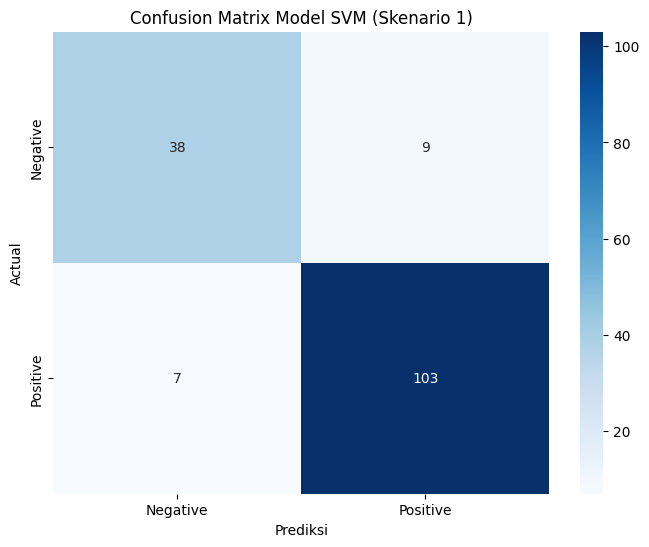

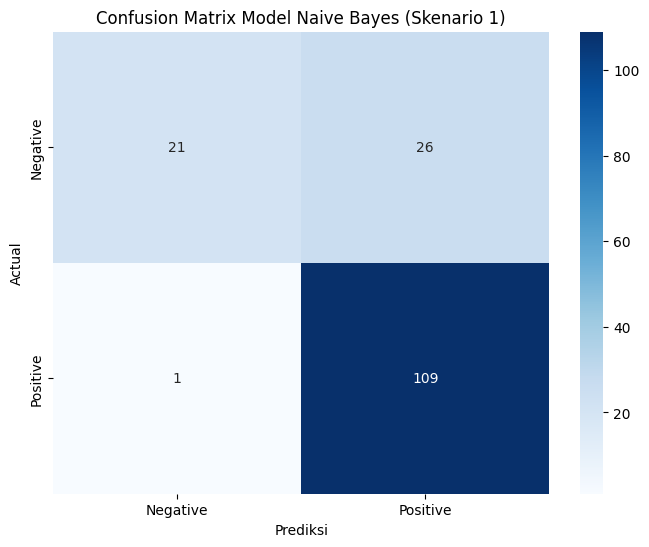

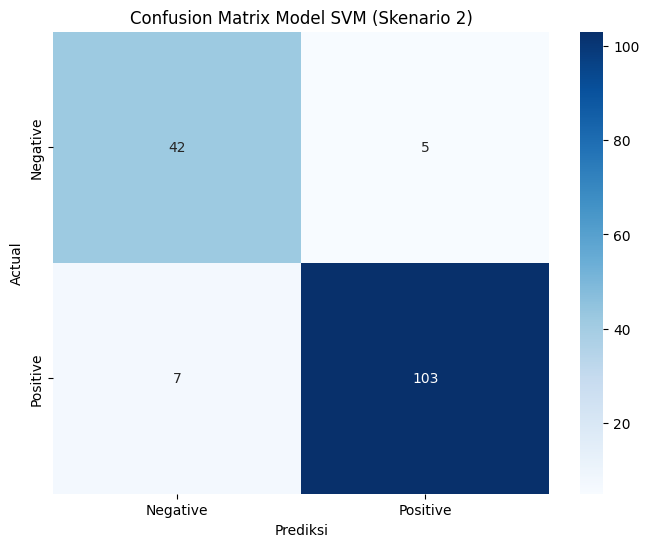

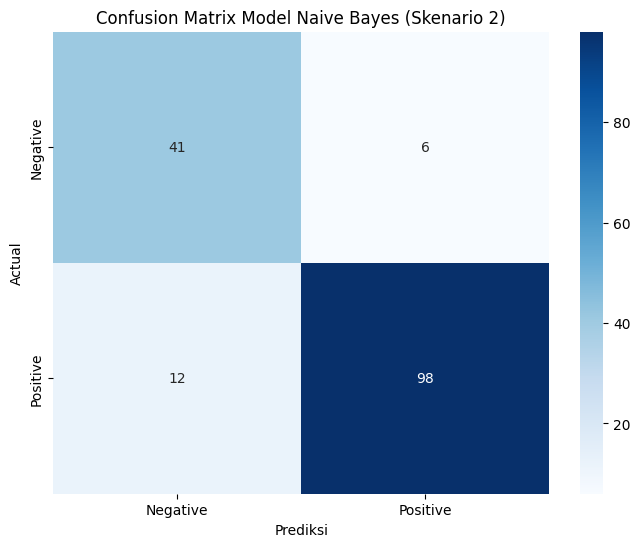

In [ ]:
# Visualisasi Confusion Matrix
# Skenario 1: TF-IDF
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model SVM (Skenario 1)')
plt.show()

print("\n")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', xticklabels=model_nb.classes_, yticklabels=model_nb.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Naive Bayes (Skenario 1)')
plt.show()

print("\n")

# Skenario 2: TF-IDF + SMOTE
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_smote, annot=True, fmt='d', cmap='Blues', xticklabels=model_svm.classes_, yticklabels=model_svm.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model SVM (Skenario 2)')
plt.show()

print("\n")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb_smote, annot=True, fmt='d', cmap='Blues', xticklabels=model_nb.classes_, yticklabels=model_nb.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Naive Bayes (Skenario 2)')
plt.show()

**WORDCLOUD** TIAP KELAS SENTIMEN

Negatif

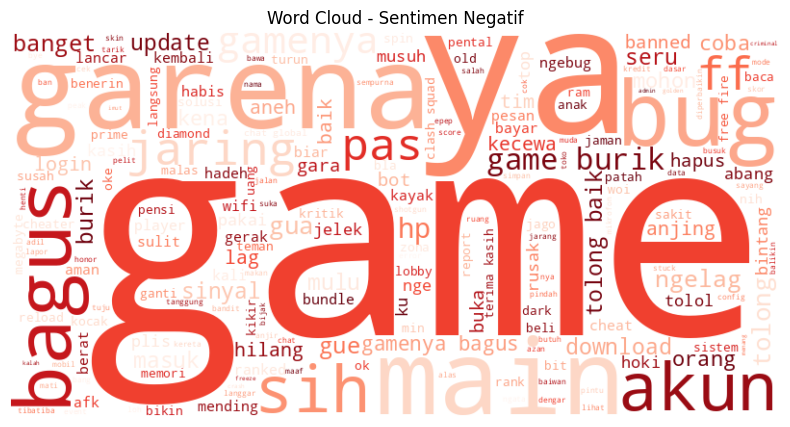

In [ ]:
# Filter for negative sentiment reviews
text_negatif = df_ulasan[df_ulasan['Sentiment'] == 'Negative']['Hasil Stemming'].str.cat(sep=' ')

# Buat word cloud dengan skema warna merah
wordcloud_merah = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'  # Skema warna merah
).generate(text_negatif)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_merah, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Sentimen Negatif")
plt.show()

Positif

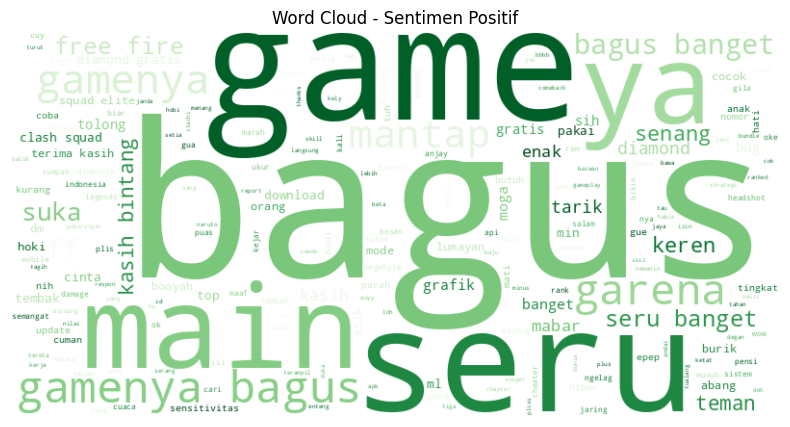

In [ ]:
# Filter for negative sentiment reviews
text_positif = df_ulasan[df_ulasan['Sentiment'] == 'Positive']['Hasil Stemming'].str.cat(sep=' ')

# Buat word cloud dengan skema warna hijau
wordcloud_positif = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens'  # Skema warna hijau
).generate(text_positif)

# Tampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Sentimen Positif")
plt.show()

**GRAFIK BARCHART**

Skenario 1 **BASELINE**

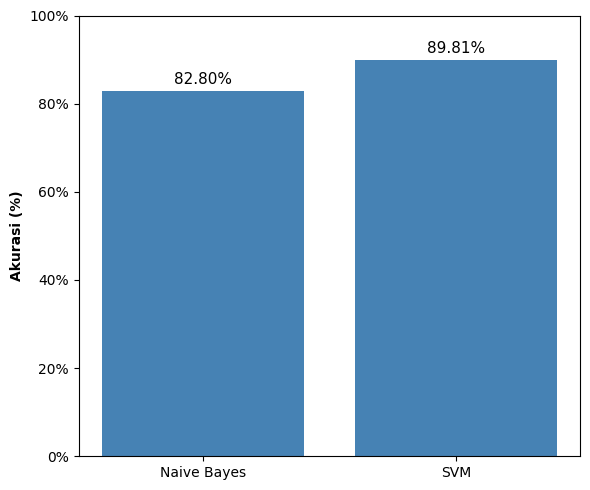

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# Data untuk plot
model_names = ['Naive Bayes', 'SVM']
accuracy_scores = [akurasi_nb, akurasi_svm]

# Buat bar chart
plt.figure(figsize=(6, 5))
bars = plt.bar(model_names, [score * 100 for score in accuracy_scores], color='steelblue')

# Tambahkan label persen di atas batang (dua angka di belakang koma)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11)

# Pengaturan tampilan
plt.ylabel('Akurasi (%)', fontweight='bold')
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))  # <-- ini ubah jadi 0% - 100%

plt.tight_layout()
plt.show()

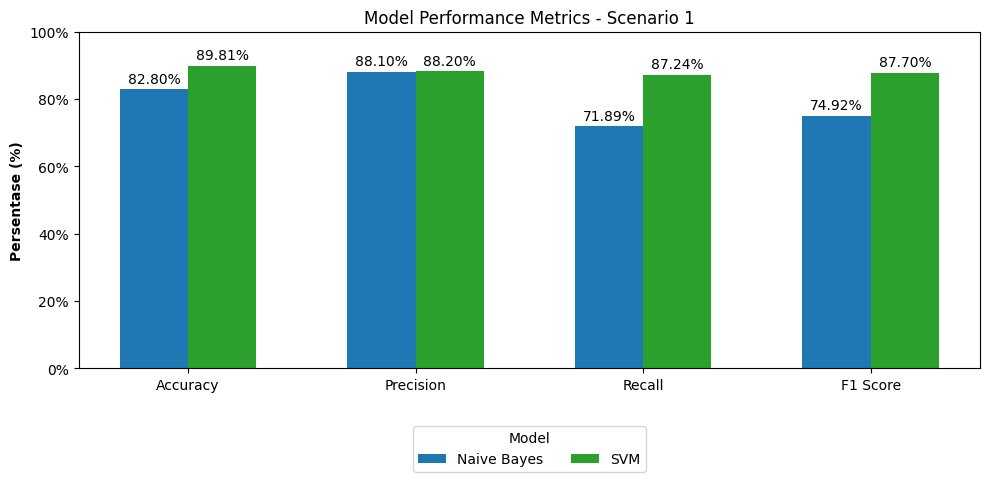

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hitung metrik evaluasi untuk Naive Bayes
akurasi_nb = accuracy_score(sentimen_uji, prediksi_nb)
presisi_nb = precision_score(sentimen_uji, prediksi_nb, average='macro')
recall_nb = recall_score(sentimen_uji, prediksi_nb, average='macro')
f1_nb = f1_score(sentimen_uji, prediksi_nb, average='macro')

# Hitung metrik evaluasi untuk SVM
akurasi_svm = accuracy_score(sentimen_uji, prediksi_svm)
presisi_svm = precision_score(sentimen_uji, prediksi_svm, average='macro')
recall_svm = recall_score(sentimen_uji, prediksi_svm, average='macro')
f1_svm = f1_score(sentimen_uji, prediksi_svm, average='macro')

# Data untuk visualisasi
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
naive_bayes_scores = [akurasi_nb, presisi_nb, recall_nb, f1_nb]
svm_scores = [akurasi_svm, presisi_svm, recall_svm, f1_svm]

x = np.arange(len(labels))  # posisi label
width = 0.3  # lebar batang

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, naive_bayes_scores, width, label='Naive Bayes', color='#1f77b4')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM', color='#2ca02c')

# Tambahkan nilai dalam persentase di atas batang
for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        persentase = yval * 100
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{persentase:.2f}%',
                ha='center', va='bottom', fontsize=10)

# Pengaturan plot
ax.set_ylabel('Persentase (%)',  fontweight='bold')
ax.set_title('Model Performance Metrics - Scenario 1')
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)  # dari 0 sampai 100% dalam skala 0-1
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # ubah ke persentase

ax.legend(title='Model', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

Skenario 2 **OVERSAMPLING**

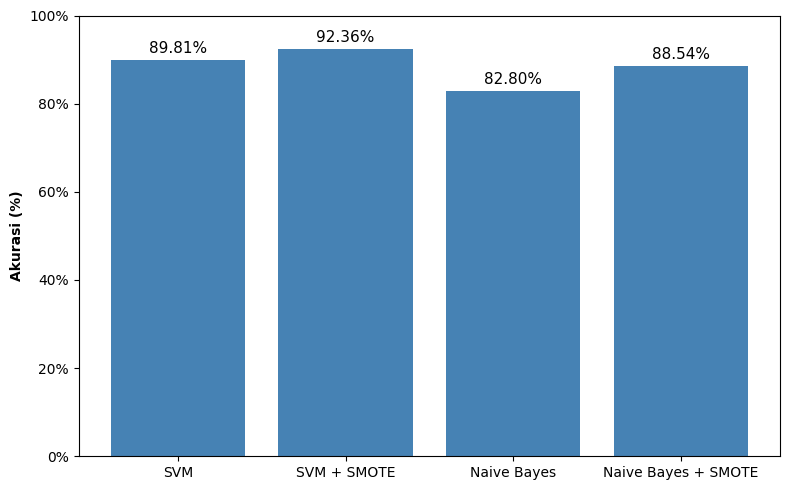

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data untuk plot
model_names = ['SVM', 'SVM + SMOTE', 'Naive Bayes', 'Naive Bayes + SMOTE']
accuracy_scores = [akurasi_svm, akurasi_svm_smote, akurasi_nb, akurasi_nb_smote]

# Buat bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [score * 100 for score in accuracy_scores], color='steelblue')

# Tambahkan label persen di atas batang (dua angka di belakang koma)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11)

# Pengaturan tampilan
plt.ylabel('Akurasi (%)',  fontweight='bold')
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))  # <-- ini ubah jadi 0% - 100%

plt.tight_layout()
plt.show()

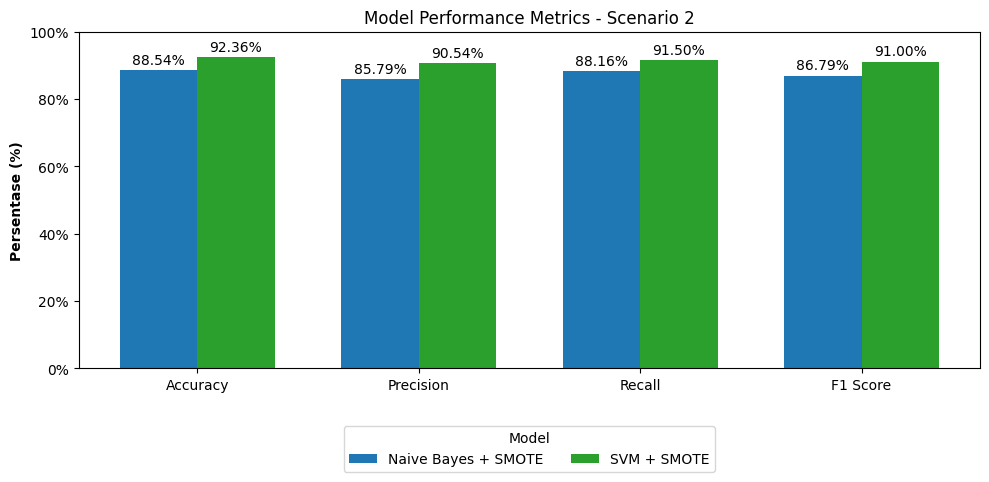

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hitung metrik evaluasi untuk Naive Bayes
akurasi_nb_smote = accuracy_score(sentimen_uji, prediksi_nb_smote)
presisi_nb_smote = precision_score(sentimen_uji, prediksi_nb_smote, average='macro')
recall_nb_smote = recall_score(sentimen_uji, prediksi_nb_smote, average='macro')
f1_nb_smote = f1_score(sentimen_uji, prediksi_nb_smote, average='macro')

# Hitung metrik evaluasi untuk SVM
akurasi_svm_smote = accuracy_score(sentimen_uji, prediksi_svm_smote)
presisi_svm_smote = precision_score(sentimen_uji, prediksi_svm_smote, average='macro')
recall_svm_smote = recall_score(sentimen_uji, prediksi_svm_smote, average='macro')
f1_svm_smote = f1_score(sentimen_uji, prediksi_svm_smote, average='macro')

# Data untuk visualisasi
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
naive_bayes_scores = [akurasi_nb_smote, presisi_nb_smote, recall_nb_smote, f1_nb_smote]
svm_scores = [akurasi_svm_smote, presisi_svm_smote, recall_svm_smote, f1_svm_smote]

x = np.arange(len(labels))  # posisi label
width = 0.35  # lebar batang

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, naive_bayes_scores, width, label='Naive Bayes + SMOTE', color='#1f77b4')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM + SMOTE', color='#2ca02c')

# Tambahkan nilai dalam persentase di atas batang
for bars in [bars1, bars2]:
    for bar in bars:
        yval = bar.get_height()
        persentase = yval * 100
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{persentase:.2f}%',
                ha='center', va='bottom', fontsize=10)

# Pengaturan plot
ax.set_ylabel('Persentase (%)', fontweight='bold')
ax.set_title('Model Performance Metrics - Scenario 2')
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, 1)  # dari 0 sampai 100% dalam skala 0-1
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # ubah ke persentase

ax.legend(title='Model', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.tight_layout()
plt.show()

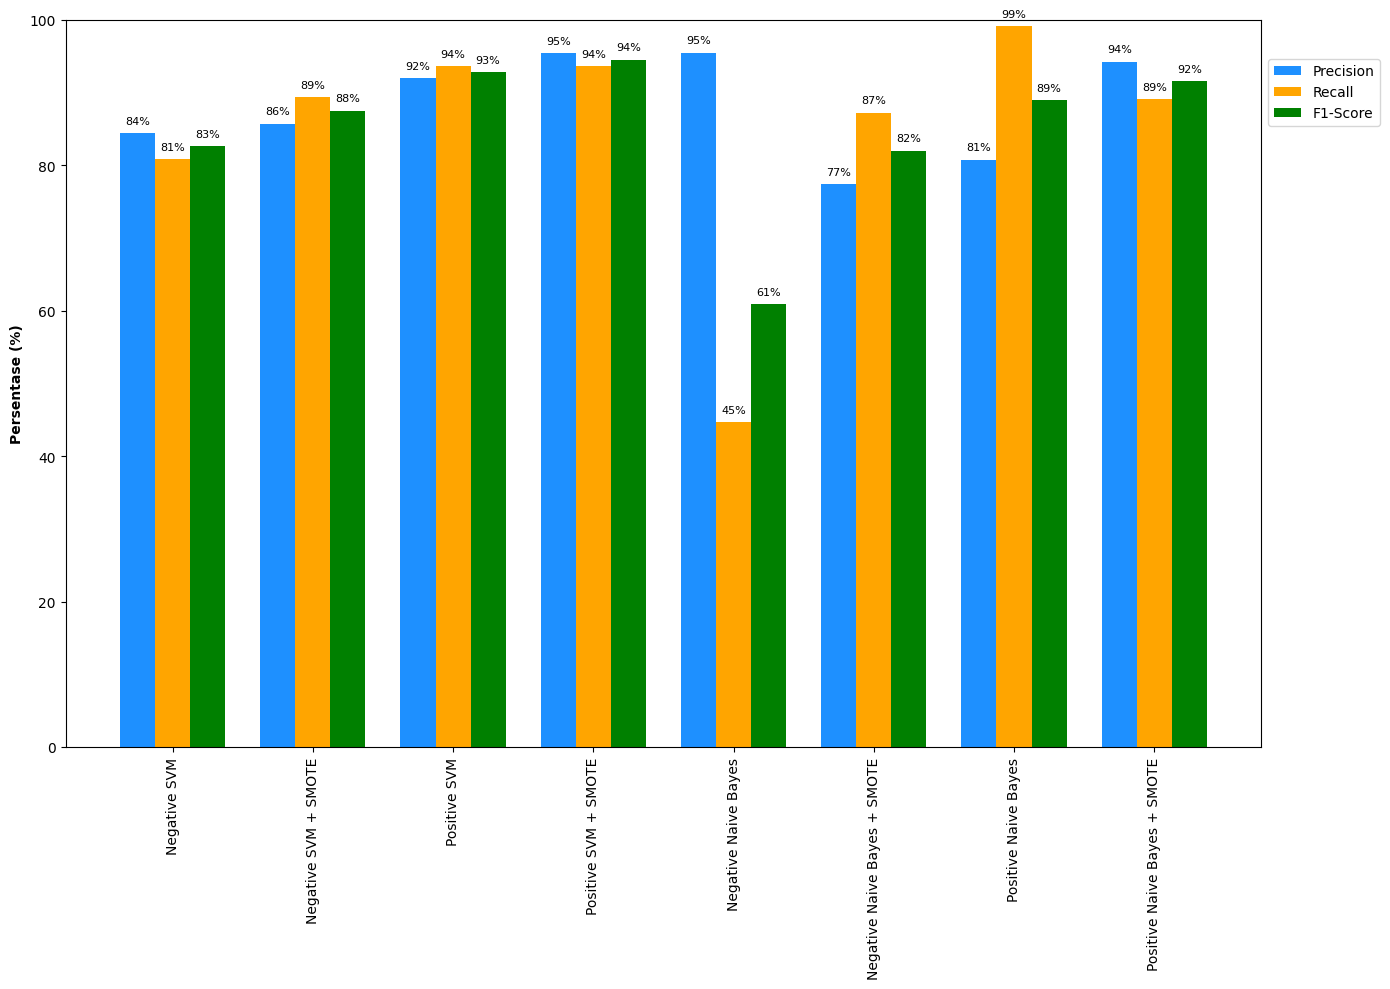

In [ ]:
report_svm_tfidf = classification_report(sentimen_uji, prediksi_svm, output_dict=True)
report_nb_tfidf = classification_report(sentimen_uji, prediksi_nb, output_dict=True)
report_svm_smote = classification_report(sentimen_uji, prediksi_svm_smote, output_dict=True)
report_nb_smote = classification_report(sentimen_uji, prediksi_nb_smote, output_dict=True)

model_names = ['Negative SVM', 'Negative SVM + SMOTE', 'Positive SVM', 'Positive SVM + SMOTE', 'Negative Naive Bayes', 'Negative Naive Bayes + SMOTE', 'Positive Naive Bayes', 'Positive Naive Bayes + SMOTE']

# Precision, Recall, F1-Score (isi sesuai hasil classification_report)
precision_score = [report_svm_tfidf['Negative']['precision'],
                   report_svm_smote['Negative']['precision'],
                   report_svm_tfidf['Positive']['precision'],
                   report_svm_smote['Positive']['precision'],
                   report_nb_tfidf['Negative']['precision'],
                   report_nb_smote['Negative']['precision'],
                   report_nb_tfidf['Positive']['precision'],
                   report_nb_smote['Positive']['precision']
]

recall_score = [report_svm_tfidf['Negative']['recall'],
                report_svm_smote['Negative']['recall'],
                report_svm_tfidf['Positive']['recall'],
                report_svm_smote['Positive']['recall'],
                report_nb_tfidf['Negative']['recall'],
                report_nb_smote['Negative']['recall'],
                report_nb_tfidf['Positive']['recall'],
                report_nb_smote['Positive']['recall']
]

f1_score = [report_svm_tfidf['Negative']['f1-score'],
            report_svm_smote['Negative']['f1-score'],
            report_svm_tfidf['Positive']['f1-score'],
            report_svm_smote['Positive']['f1-score'],
            report_nb_tfidf['Negative']['f1-score'],
            report_nb_smote['Negative']['f1-score'],
            report_nb_tfidf['Positive']['f1-score'],
            report_nb_smote['Positive']['f1-score']
]

# Posisi sumbu x
x = np.arange(len(model_names))
width = 0.25  # Lebar batang

# Buat plot
plt.figure(figsize=(14, 10))
bar1 = plt.bar(x - width, [p * 100 for p in precision_score], width, label='Precision', color='dodgerblue')
bar2 = plt.bar(x, [r * 100 for r in recall_score], width, label='Recall', color='orange')
bar3 = plt.bar(x + width, [f * 100 for f in f1_score], width, label='F1-Score', color='green')

# Tambahkan nilai di atas batang (pakai persen)
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.0f}%',
                 ha='center', va='bottom', fontsize=8)

plt.xticks(x, model_names, rotation=90)
plt.ylabel('Persentase (%)',  fontweight='bold')
plt.ylim(0, 100)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.9))
plt.tight_layout()

# Tampilkan plot
plt.show()

# **Melakukan Pengujian**

In [ ]:
# saat pengujian
contoh_ulasan = ["gamenya bagus tapi sarankan lawannya seimbang bukan lawan yg sudah lama main"]
contoh_ulasan_tfidf = TfidfVectorizer.transform(contoh_ulasan)

In [ ]:
# Prediksi sentimen menggunakan model terbaik SVM
prediksi_sentimen = model_svm.predict(contoh_ulasan_tfidf)
prediksi_sentimen

array(['Positive'], dtype=object)

In [ ]:
# saat pengujian
contoh_ulasan = ["ff semakin update semakin kagak seru"]
contoh_ulasan_tfidf = TfidfVectorizer.transform(contoh_ulasan)

In [ ]:
# Prediksi sentimen menggunakan model terbaik SVM
prediksi_sentimen = model_svm.predict(contoh_ulasan_tfidf)
prediksi_sentimen

array(['Positive'], dtype=object)